# Simulation of the Damped Harmonic Oscillator

## Aim
To numerically solve the differential equation of a damped harmonic oscillator using the Euler-Cromer algorithm. Specifically, the objective is to simulate and plot the displacement $x(t)$ over time for at least three complete cycles, and to investigate the effects of the damping coefficient $b$ to demonstrate underdamped, critically damped, and overdamped oscillations.

## Mathematical Analysis

The equation of motion for a damped harmonic oscillator is given by the second-order linear differential equation:
$$\ddot{x} + 2b\dot{x} + \omega_0^2 x = 0$$

Where:
* $x$ is the displacement.
* $b$ is the damping parameter per unit mass.
* $\omega_0$ is the natural angular frequency of the undamped system.

For this simulation, the initial conditions are set to $x(0) = 0$ and $v(0) = 1$, with a natural frequency of $\omega_0 = 1$. The period of the undamped system is $T = \frac{2\pi}{\omega_0} \approx 6.28$. To simulate at least three complete cycles, we will run the simulation up to $t = 25$.

**1. Damping Regimes:**
The behavior of the oscillator is dictated by the relative values of $b$ and $\omega_0$:
* **Underdamped ($b < \omega_0$):** The system oscillates with an amplitude that decays exponentially over time. We will use $b = 0.2$.
* **Critically Damped ($b = \omega_0$):** The system returns to equilibrium as rapidly as possible without oscillating. We will use $b = 1.0$.
* **Overdamped ($b > \omega_0$):** The system returns to equilibrium slowly without oscillating, governed by strong resistive forces. We will use $b = 2.0$.

**2. The Euler-Cromer Algorithm:**
To apply numerical integration, we decompose the second-order ODE into a system of two coupled first-order ODEs. Let $v = \dot{x}$, then the acceleration is:
$$\dot{v} = -2bv - \omega_0^2 x$$

The Euler-Cromer method explicitly calculates the new velocity first, and then uses that updated velocity to calculate the new position, ensuring better stability for oscillating systems:
1.  $v_{n+1} = v_n + (-2b v_n - \omega_0^2 x_n) \Delta t$
2.  $x_{n+1} = x_n + v_{n+1} \Delta t$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
omega0 = 1.0         # Natural frequency
t_max = 25.0         # Total time (covers ~4 cycles since T ≈ 6.28)
dt = 0.01            # Time step size
N = int(t_max / dt)  # Total number of time steps

# Time array
t = np.linspace(0, t_max, N)

# The three damping coefficients to simulate
b_values = {
    'Underdamped (b=0.2)': 0.2,
    'Critically Damped (b=1.0)': 1.0,
    'Overdamped (b=2.0)': 2.0
}

In [3]:
def solve_damped_oscillator(b, omega0, dt, N):
    x = np.zeros(N)
    v = np.zeros(N)
    
    # Apply initial conditions: x(0) = 0, v(0) = 1
    x[0] = 0.0
    v[0] = 1.0
    
    for n in range(N - 1):
        # Calculate acceleration based on current state
        a_n = -2 * b * v[n] - (omega0**2) * x[n]
        
        # Euler-Cromer updates
        v[n+1] = v[n] + a_n * dt       # Update velocity first
        x[n+1] = x[n] + v[n+1] * dt    # Use new velocity to update position
        
    return x

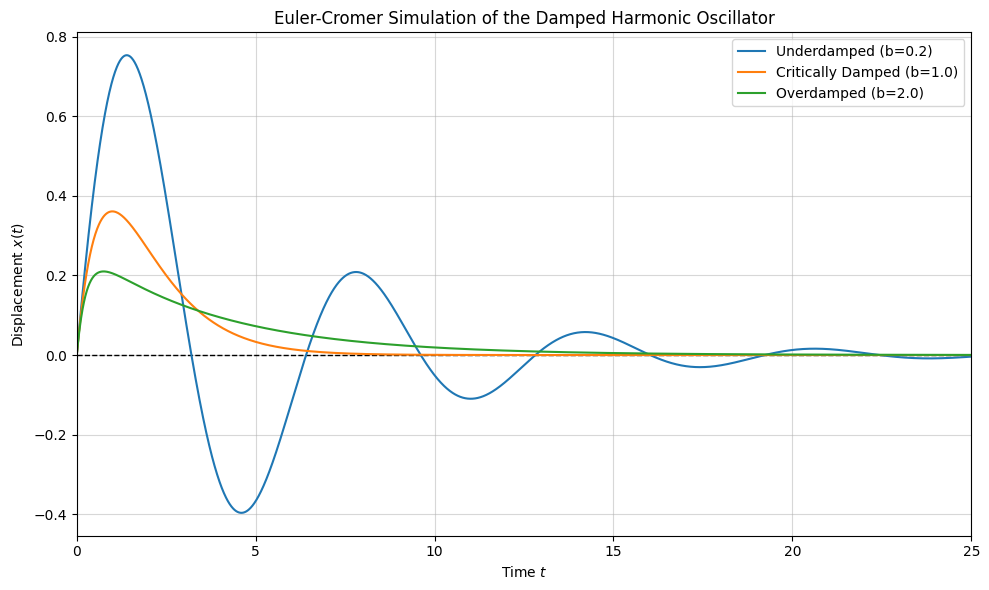

In [4]:
plt.figure(figsize=(10, 6))

# Plot a horizontal line representing the equilibrium position
plt.axhline(0, color='black', linewidth=1, linestyle='--')

# Run and plot the simulation for each regime
for label, b in b_values.items():
    x_sim = solve_damped_oscillator(b, omega0, dt, N)
    plt.plot(t, x_sim, label=label, linewidth=1.5)

plt.title('Euler-Cromer Simulation of the Damped Harmonic Oscillator')
plt.xlabel('Time $t$')
plt.ylabel('Displacement $x(t)$')
plt.xlim(0, t_max)
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## Observations

Based on the plotted trajectories:
1. **Underdamped Case ($b = 0.2$):** The displacement curve crosses the equilibrium axis multiple times. The system exhibits periodic oscillations, but the maximum amplitude strictly decreases with each successive cycle, illustrating the continuous dissipation of energy.
2. **Critically Damped Case ($b = 1.0$):** The displacement rises to a single initial peak and then rapidly decays toward $x=0$. It represents the fastest return to equilibrium without any zero-crossings (no bouncing).
3. **Overdamped Case ($b = 2.0$):** The displacement peaks at a lower maximum value than the critically damped case and takes a significantly longer time to decay back toward $x=0$. 